# Noise-diode drift calibration

Anchor: recal-drift pointings observed throughout each session.

1. Load all recal dumps, preprocess (fftshift + RFI flag).
2. Visit-average each (pol, LO) into a band-averaged scalar p_on, p_off
   with SEM measured from dump-to-dump scatter.
3. Plot T_sys(t) per pol per pointing with session-span shading.
4. Pick a single anchor (one A-B pair) and derive Tcal00, Tcal11 plus
   per-pointing T_B_X under the assumption that T_sys at the recal
   pointings is stable across a session.
5. Propagate to a scalar Tcal_pol(t) per visit per pointing.
6. Cross-pointing renormalisation: rescale B onto A's ladder using all
   admissible A-B pairs, diagnose anchor-bias vs real differential drift.


## Assumptions and calibration chain

This notebook treats the noise-diode temperature `Tcal_pol(t)` as drifting
in time and reconstructs it from recal-visit data using three physical
bridges:

1. **Cross-pointing tie (same pol, near-simultaneous):** at two times
   `t0_A` and `t0_B` separated by less than `DT_MAX_SEC` (default 600 s),
   the diode has not drifted appreciably, so
   `Tcal11A(t0_A) = Tcal11B(t0_B)`. The absolute scale is fixed by
   stipulation: `Tcal11A(t0_A) = 100 K`, a placeholder to be refined
   later against a known extended object (e.g. `cal_intensity.tex`).

2. **Cross-pol bridge (same time, same pointing):** unpolarised galactic
   HI gives `T_B` independent of pol, so
   `T_sys_00X(nu) * R_00X(nu) = T_sys_11X(nu) * R_11X(nu) = T_B_X(nu)`,
   letting us derive pol-0 calibration from pol-1 at every recal visit.

3. **Constant `T_B(nu)` at each recal pointing:** the recal targets are
   sidereally tracked at fixed (RA, Dec), so the beam integrates the
   same patch of sky every visit. With `T_B_X(nu)` frozen by the anchor,
   `T_sys_pol(nu, t, X) = T_B_X(nu) / R_pol(nu, t, X)` at every later
   visit, giving `Tcal_pol(nu, t, X) = T_sys_pol(nu, t, X) *
   (P_on - P_off)_pol(nu, t, X) / P_off_pol(nu, t, X)`.

### Explicit assumptions

- **Pointing-independent diode.** `Tcal_pol(t)` depends only on time,
  not on telescope pointing. The diode is in the receiver chain, so
  this is standard; divergence between `Tcal11A(t)` and `Tcal11B(t)` at
  subsequent pair times is the diagnostic.
- **HI unpolarised.** Required for the cross-pol bridge. True for HI;
  the bridge is sensitive to band-localised polarised RFI, so it must
  be evaluated on RFI-clean channels.
- **`T_sys` channel-flat.** Receiver noise is broadband, so `T_sys` is
  treated as effectively flat in frequency; HI line structure enters
  through `R(nu)`. This is implicit in `g * R = T_B`.
- **Recal pointings sidereally tracked.** Same `T_B(nu)` every visit;
  if the targets are alt/az-parked the assumption fails.
- **Time-proximity threshold `DT_MAX_SEC = 600 s`.** Diode-drift
  timescale is assumed slow compared to 600 s.
- **HI present at recal pointings.** The HI line must be detectable in
  the frequency-switched ratio `R_pol` at each recal pointing for the
  cross-pol bridge to carry signal.
- **First cross-pointing pair fixes the anchor.** Subsequent pairs are
  consistency checks, not refinements.

### Chain summary

```
Tcal11A(t0_A) := 100 K                          (anchor stipulation)
Tcal11B(t0_B) := Tcal11A(t0_A)                  (cross-pointing tie, |dt|<=600s)
T_sys_11X(nu, t0) = Tcal11X * P_off / dP        (X in {A, B})
T_B_X(nu)         = T_sys_11X(nu, t0) * R_11X(nu, t0)  (frozen per pointing)
T_sys_00X(nu, t0) = T_sys_11X * R_11X / R_00X   (cross-pol bridge)
Tcal00X(nu, t0)   = T_sys_00X * dP_00X / P_off_00X
For all later t:
  T_sys_pol(nu, t, X) = T_B_X(nu) / R_pol(nu, t, X)
  Tcal_pol(nu, t, X)  = T_sys_pol * dP_pol / P_off_pol
```


## Additional assumption and known limitations

Documented separately from the input-assumption block above: one physical
assumption added during the audit, and a set of failure modes that bound
how the recovered `Tcal_pol(t)` may be used downstream.

### Pol-simultaneity (input assumption)

Polarisations 0 and 1 are sampled at the same instant, so sky-side
contributions to `T_sys` (atmosphere x airmass, ground spillover, sky
`T_B`) drift identically for both pols at the same `(t, pointing)`.
Receiver-side contributions (`T_rx_0`, `T_rx_1`) come from separate LNA
chains and may drift independently. The noise diode is pol-common only
if a single device injects into both pols (Leuschner block diagram in
`src/ugradio/lab_dish/` should be consulted to confirm).

Falsifiable consequence: at any given visit,
`[dP_0/P_off_0] / [dP_1/P_off_1]` is constant in time if the assumption
holds. A drift in this ratio indicates differential pol behaviour --
`T_rx` mismatch or pol-specific diode coupling drift (the known pol-0
3.2 MHz coupling issue is exactly this).

### Known limitations and failure modes

1. **Off-line `R ~ 0`.** `R_pol(nu) = (P_off^LO1 - P_off^LO2)/P_off^LO2`
   is a differential measurement carrying signal only near the HI line.
   Per-channel `T_sys = T_B / R` is therefore numerically dominated by
   noise across most of the band. Mitigation: collapse to a scalar via
   band-averaging at section 2 with scalar propagation through to section 8.

2. **`Tcal` and `T_sys` are not separable by this method.** `R(t)` is
   invariant under common-mode (LO1+LO2) gain drift, so `R(t) ~ R(t0)`
   and the propagated `T_sys(t)` is effectively frozen at the anchor
   value. The recovered "`Tcal(t)`" is therefore
   `Tcal(t) * T_sys(t0) / T_sys(t)` -- a proxy that conflates diode
   drift with system-temperature drift. For a thermally stable
   receiver this approximates `Tcal(t)`; otherwise the result is a
   composite drift indicator, not a metrology. Breaking the
   degeneracy requires an independent constraint (absolute celestial
   calibrator, Y-factor against hot/cold loads, or receiver-temperature
   telemetry).

3. **LO averaging blurs LO-specific bandpass.** `visit_mean_P` averages
   `P_on` and `P_off` across LO1 and LO2 at the same baseband-channel
   index. The two LO settings sample different sky-frequency bands, so
   the diode * bandpass response differs between them. Use the
   band-integrated scalar (section 9) as the cleaner output for
   `Tcal(t)`; do not rely on `Tcal(nu, t)` shape from section 7.

4. **No error propagation.** Per-visit noise in `R_pol` and `dP_pol`
   propagates into `Tcal_pol(t)` but is not tracked. A single noisy
   anchor visit rescales every downstream value with no uncertainty
   estimate.

5. **Anchor-visit fragility.** Transient RFI or a single bad noise-off
   dump at the anchor visit systematically biases every later derived
   `Tcal`. Sanity check against subsequent cross-pointing pairs:
   `Tcal11A(t)` and `Tcal11B(t)` should overlay within visit-level
   scatter; divergence flags either anchor corruption or breakdown of
   the no-diode-drift-in-600s assumption.

6. **Atmospheric / elevation contamination of "constant `T_B`".** The
   HI-line component of `T_B` is constant at a sidereally tracked
   pointing; the continuum + atmospheric component varies with
   elevation through opacity x airmass and ground spillover. The
   "constant `T_B(nu)`" input assumption is therefore exact for HI and
   approximate for everything else. Elevation-varying `T_sys` leaks
   into the recovered `Tcal` drift. Band-averaging at section 2 folds continuum + atmosphere directly into
   the scalar `R`; for the per-pointing constant-`T_B` model to
   remain self-consistent, the recal visits must occur at similar
   elevation, or the integrand must be restricted to RFI-clean line
   channels.

7. **Polarised RFI breaks the cross-pol bridge.** Persistent narrowband
   polarised interference inside the integration band skews `R_11/R_00`
   and corrupts `Tcal00`. The HI-unpolarised input assumption applies
   cleanly only on RFI-clean channels; full-band integration dilutes
   line-localised polarised RFI but amplifies broadband polarised
   contamination if present.

8. **Absolute scale is a 100 K stipulation.** Until recalibrated against
   a known extended object (`cal_intensity.tex` in `lab_bighorn`), all
   `Tcal` and `T_sys` values are in arbitrary units of "100 K at the
   anchor visit". Relative drift over time is meaningful; absolute
   values are not.

### Usability summary

- Scalar `Tcal_pol(t)` from the band-averaged track (section 8):
  usable as a relative drift monitor. Treat as
  `Tcal(t) * T_sys(t0)/T_sys(t)` pending degeneracy break.
- Absolute photometry: requires independent absolute calibration.


In [1]:
import sys
import datetime as dt
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Path: labs/04 (for utils/) and project root (for ugradiolab/).
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
_PROJECT_ROOT = str(Path.cwd().parent.parent)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

from utils.io import load_recal_dumps, build_session_summary
from utils.rfi import preprocess_dumps
from utils.freqswitch import build_overlap_grid

# Importing ugradiolab.plotting sets matplotlib rcParams globally
# (text.usetex=True, font sizes, tick directions, grid on by default).
from ugradiolab.plotting import (
    TEXTWIDTH_IN, textwidth_figure, subpanels, zero_line,
    LW_FINE, LW_LIGHT, ALPHA_FAINT, ALPHA_LIGHT, ALPHA_STANDARD,
    SS_STANDARD,
    NEUTRAL_COLOR, GRID_STYLE, GUIDE_STYLE, MODEL_STYLE,
)


def _tex_safe(s):
    """Escape underscores for text.usetex=True string rendering."""
    return s.replace('_', r'\_')


# Hardware (main dataset, 3.2 MHz)
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
EDGE_TRIM_MHZ = 0.256
INT_TIME_S = 16384 / SAMPLE_RATE_HZ * 1025

# Nominal noise-diode temperatures (used to define the anchor T_sys).
# pol 0 = corr00, pol 1 = corr11.
T_CAL_NOMINAL = {0: 58.0, 1: 79.0}

# Recal pointings -> sky coordinates (from scripts/main/_survey.py).
POINTING_LABELS = {
    'recal_drift':    r'$(\alpha,\delta)=(180^\circ,\,72^\circ)$',
    'recal_drift_bk': r'$(\alpha,\delta)=(90^\circ,\,72^\circ)$',
}

# Session-shading style: one flat light alpha for all spans, with
# slightly deeper grey vertical lines at each session boundary.
SESSION_SPAN_ALPHA = 0.08
SESSION_BOUNDARY_ALPHA = 0.45
SESSION_BOUNDARY_COLOR = '0.35'

VISIT_GAP_SEC = 300.0

RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

DATA_DIRS = [Path('data/main'), Path('data/nps')]

POLS = (('corr00', 0), ('corr11', 1))
LOS = ((1, F1_MHZ), (2, F2_MHZ))


def _shade_sessions(ax, session_spans):
    """Light flat-alpha shading per session + deeper boundary vlines."""
    boundaries = set()
    for t0, t1 in session_spans.values():
        ax.axvspan(t0, t1, color=NEUTRAL_COLOR,
                   alpha=SESSION_SPAN_ALPHA, zorder=0)
        boundaries.add(t0)
        boundaries.add(t1)
    for t in boundaries:
        ax.axvline(t, color=SESSION_BOUNDARY_COLOR,
                   alpha=SESSION_BOUNDARY_ALPHA,
                   lw=LW_FINE, zorder=1)

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load all recal dumps

In [2]:
recal_records = load_recal_dumps(DATA_DIRS)
print(f'Loaded {len(recal_records)} recal dumps')
print('Pointings:', sorted({r["target_id"] for r in recal_records}))

# fftshift + per-pol RFI flag (in place).
preprocess_dumps(
    recal_records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)

session_summary = build_session_summary(recal_records, INT_TIME_S)
session_summary

Loaded 900 recal dumps
Pointings: ['recal_drift', 'recal_drift_bk']


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:53,2026-05-14 02:43,50.2,1,48,8.4
1,main/session_002,2026-05-14 07:29,2026-05-14 09:38,129.3,2,108,7.3
2,main/session_003,2026-05-14 09:38,2026-05-14 12:22,163.4,2,132,7.1
3,main/session_004,2026-05-14 12:25,2026-05-14 15:20,174.8,2,132,6.6
4,main/session_005,2026-05-14 15:20,2026-05-14 18:01,160.7,1,108,5.9
5,main/session_006,2026-05-14 18:01,2026-05-14 20:07,126.2,2,96,6.7
6,main/session_007,2026-05-14 20:08,2026-05-14 23:24,196.5,2,120,5.3
7,main/session_008,2026-05-14 23:25,2026-05-14 23:26,1.1,1,12,93.7
8,nps/session_001,2026-05-14 02:56,2026-05-14 06:28,211.8,2,144,5.9


## 2. Outlier-dump filter, then per-visit averaged on/off power

Apply the same outlier-dump filter used by `main_scan_load.ipynb`,
then cluster recal dumps by (session, target_id) and time gap. For
each visit and each (pol, LO), average the noise-on dumps to
`P_on(nu)` and the noise-off dumps to `P_off(nu)`.


In [3]:
import warnings
from utils.rfi import flag_outlier_dumps

grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']

# INT_MASK: the band over which every visit collapses to a scalar.
# Full usable overlap with the DC bin excluded.  Baked in here so all
# downstream sections work in scalar arithmetic.
INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False
print(f'Integration mask: {INT_MASK.sum()} channels '
      f'({grid["f_overlap_lo"]:.3f} - {grid["f_overlap_hi"]:.3f} MHz, DC excluded)')

flagged = flag_outlier_dumps(
    recal_records,
    dev_thresh=0.05,
    frac_thresh=0.05,
    min_group_size=3,
)
print(f'{len(flagged)} outlier recal dumps removed')


def _band_scalars(dumps, mask):
    """Per-dump band-average over `mask`; returns 1-D array of scalars."""
    if not dumps:
        return np.array([])
    return np.array([np.nanmean(d[mask]) for d in dumps])


def _mean_sem(scalars):
    """Visit mean and SEM = std(ddof=1)/sqrt(N) of per-dump scalars."""
    n = len(scalars)
    if n == 0:
        return np.nan, np.nan
    mu = float(np.nanmean(scalars))
    if n < 2:
        return mu, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        sigma = float(np.nanstd(scalars, ddof=1))
    return mu, sigma / np.sqrt(n)


def build_gain_visits(records, visit_gap_sec=VISIT_GAP_SEC):
    """Cluster recal dumps into visits; band-average each dump to a scalar
    and store the visit mean + SEM per (pol, LO).  Everything downstream
    works in scalar arithmetic from this point on.
    """
    groups = defaultdict(list)
    for r in records:
        groups[(r['session'], r['target_id'])].append(r)

    visits = []
    for (session, target_id), grp in groups.items():
        grp = sorted(grp, key=lambda r: r['time'])
        runs = [[grp[0]]]
        for r in grp[1:]:
            if r['time'] - runs[-1][-1]['time'] > visit_gap_sec:
                runs.append([r])
            else:
                runs[-1].append(r)

        for visit_idx, run in enumerate(runs):
            v = {
                'session': session,
                'target_id': target_id,
                'visit_idx': visit_idx,
                't_mid': float(np.mean([r['time'] for r in run])),
                'alt_mean': float(np.mean([r['alt'] for r in run])),
                'gl': run[0]['gl'],
                'gb': run[0]['gb'],
                'n_dumps': len(run),
            }
            for pol_key, pol_idx in POLS:
                for lo_id, lo_mhz in LOS:
                    on = [r[pol_key] for r in run
                          if r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    off = [r[pol_key] for r in run
                           if not r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    pon,  spon  = _mean_sem(_band_scalars(on,  INT_MASK))
                    poff, spoff = _mean_sem(_band_scalars(off, INT_MASK))
                    v[f'p_on_pol{pol_idx}_lo{lo_id}']   = pon
                    v[f'p_off_pol{pol_idx}_lo{lo_id}']  = poff
                    v[f'sp_on_pol{pol_idx}_lo{lo_id}']  = spon
                    v[f'sp_off_pol{pol_idx}_lo{lo_id}'] = spoff
                    v[f'n_on_pol{pol_idx}_lo{lo_id}']   = len(on)
                    v[f'n_off_pol{pol_idx}_lo{lo_id}']  = len(off)
            visits.append(v)
    return sorted(visits, key=lambda v: v['t_mid'])


gain_visits = build_gain_visits(recal_records)
print(f'{len(gain_visits)} visits total')
print('Per pointing:',
      {tid: sum(1 for v in gain_visits if v['target_id'] == tid)
       for tid in sorted({v["target_id"] for v in gain_visits})})

# Diagnostic: typical fractional SEM on band-averaged P_off.
sem_fracs = []
for v in gain_visits:
    for pol_idx in (0, 1):
        for lo_id, _ in LOS:
            p  = v[f'p_off_pol{pol_idx}_lo{lo_id}']
            sp = v[f'sp_off_pol{pol_idx}_lo{lo_id}']
            if np.isfinite(p) and np.isfinite(sp) and p > 0:
                sem_fracs.append(sp / p)
sem_fracs = np.asarray(sem_fracs)
print(f'Median fractional SEM on band-averaged P_off: '
      f'{np.nanmedian(sem_fracs)*100:.3f}%  '
      f'(IQR {np.nanpercentile(sem_fracs, 25)*100:.3f}-'
      f'{np.nanpercentile(sem_fracs, 75)*100:.3f}%)')


Integration mask: 449 channels (1419.796 - 1421.201 MHz, DC excluded)
0 outlier recal dumps removed
75 visits total
Per pointing: {'recal_drift': 48, 'recal_drift_bk': 27}
Median fractional SEM on band-averaged P_off: 0.033%  (IQR 0.022-0.047%)


## 3. T_sys(t) per pointing

Scalar from the start: each visit has band-averaged `p_on`, `p_off` per
(pol, LO) with SEM.  T_sys = T_cal_nominal * p_off / (p_on - p_off);
the two LOs are combined by inverse-variance weighted mean.


In [4]:
def _lo_combine(vals_sigmas):
    """Inverse-variance combine a list of (value, sigma) pairs."""
    vals = np.array([v for v, _ in vals_sigmas], dtype=float)
    sigs = np.array([s for _, s in vals_sigmas], dtype=float)
    good = np.isfinite(vals) & np.isfinite(sigs) & (sigs > 0)
    if not np.any(good):
        return np.nan, np.nan
    w = 1.0 / sigs[good]**2
    mu = float(np.sum(w * vals[good]) / np.sum(w))
    return mu, float(1.0 / np.sqrt(np.sum(w)))


def visit_tsys_lo(visit, pol_idx, lo_id, T_cal):
    """Per-LO scalar T_sys = T_cal * p_off / (p_on - p_off) with SEM.

    var_T = (T_cal/dp^2)^2 * (p_on^2 sp_off^2 + p_off^2 sp_on^2)
    """
    pon   = visit[f'p_on_pol{pol_idx}_lo{lo_id}']
    poff  = visit[f'p_off_pol{pol_idx}_lo{lo_id}']
    spon  = visit[f'sp_on_pol{pol_idx}_lo{lo_id}']
    spoff = visit[f'sp_off_pol{pol_idx}_lo{lo_id}']
    if not (np.isfinite(pon) and np.isfinite(poff)
            and np.isfinite(spon) and np.isfinite(spoff)):
        return np.nan, np.nan
    dp = pon - poff
    if dp <= 0:
        return np.nan, np.nan
    tsys = T_cal * poff / dp
    var  = (T_cal / dp**2)**2 * (pon**2 * spoff**2 + poff**2 * spon**2)
    return float(tsys), float(np.sqrt(var))


rows = []
for v in gain_visits:
    for pol_idx in (0, 1):
        T_cal = T_CAL_NOMINAL[pol_idx]
        per_lo = [visit_tsys_lo(v, pol_idx, lo_id, T_cal) for lo_id, _ in LOS]
        tsys, sigma_tsys = _lo_combine(per_lo)
        rows.append({
            'session': v['session'],
            'target_id': v['target_id'],
            'visit_idx': v['visit_idx'],
            't_mid': v['t_mid'],
            'pol': pol_idx,
            'tsys_lo1': per_lo[0][0], 'sigma_tsys_lo1': per_lo[0][1],
            'tsys_lo2': per_lo[1][0], 'sigma_tsys_lo2': per_lo[1][1],
            'tsys': tsys,             'sigma_tsys': sigma_tsys,
            'alt': v['alt_mean'],
        })
tsys_df = pd.DataFrame(rows)
tsys_df[['session', 'target_id', 'pol', 'tsys', 'sigma_tsys']].head(6)


,session,target_id,pol,tsys,sigma_tsys
0,main/session_001,recal_drift,0,3842.200159,112.785862
1,main/session_001,recal_drift,1,243.852169,0.458497
2,main/session_001,recal_drift,0,2906.893703,36.413889
3,main/session_001,recal_drift,1,215.421274,0.396480
4,main/session_001,recal_drift,0,2652.610160,39.267872
5,main/session_001,recal_drift,1,210.411810,0.335181


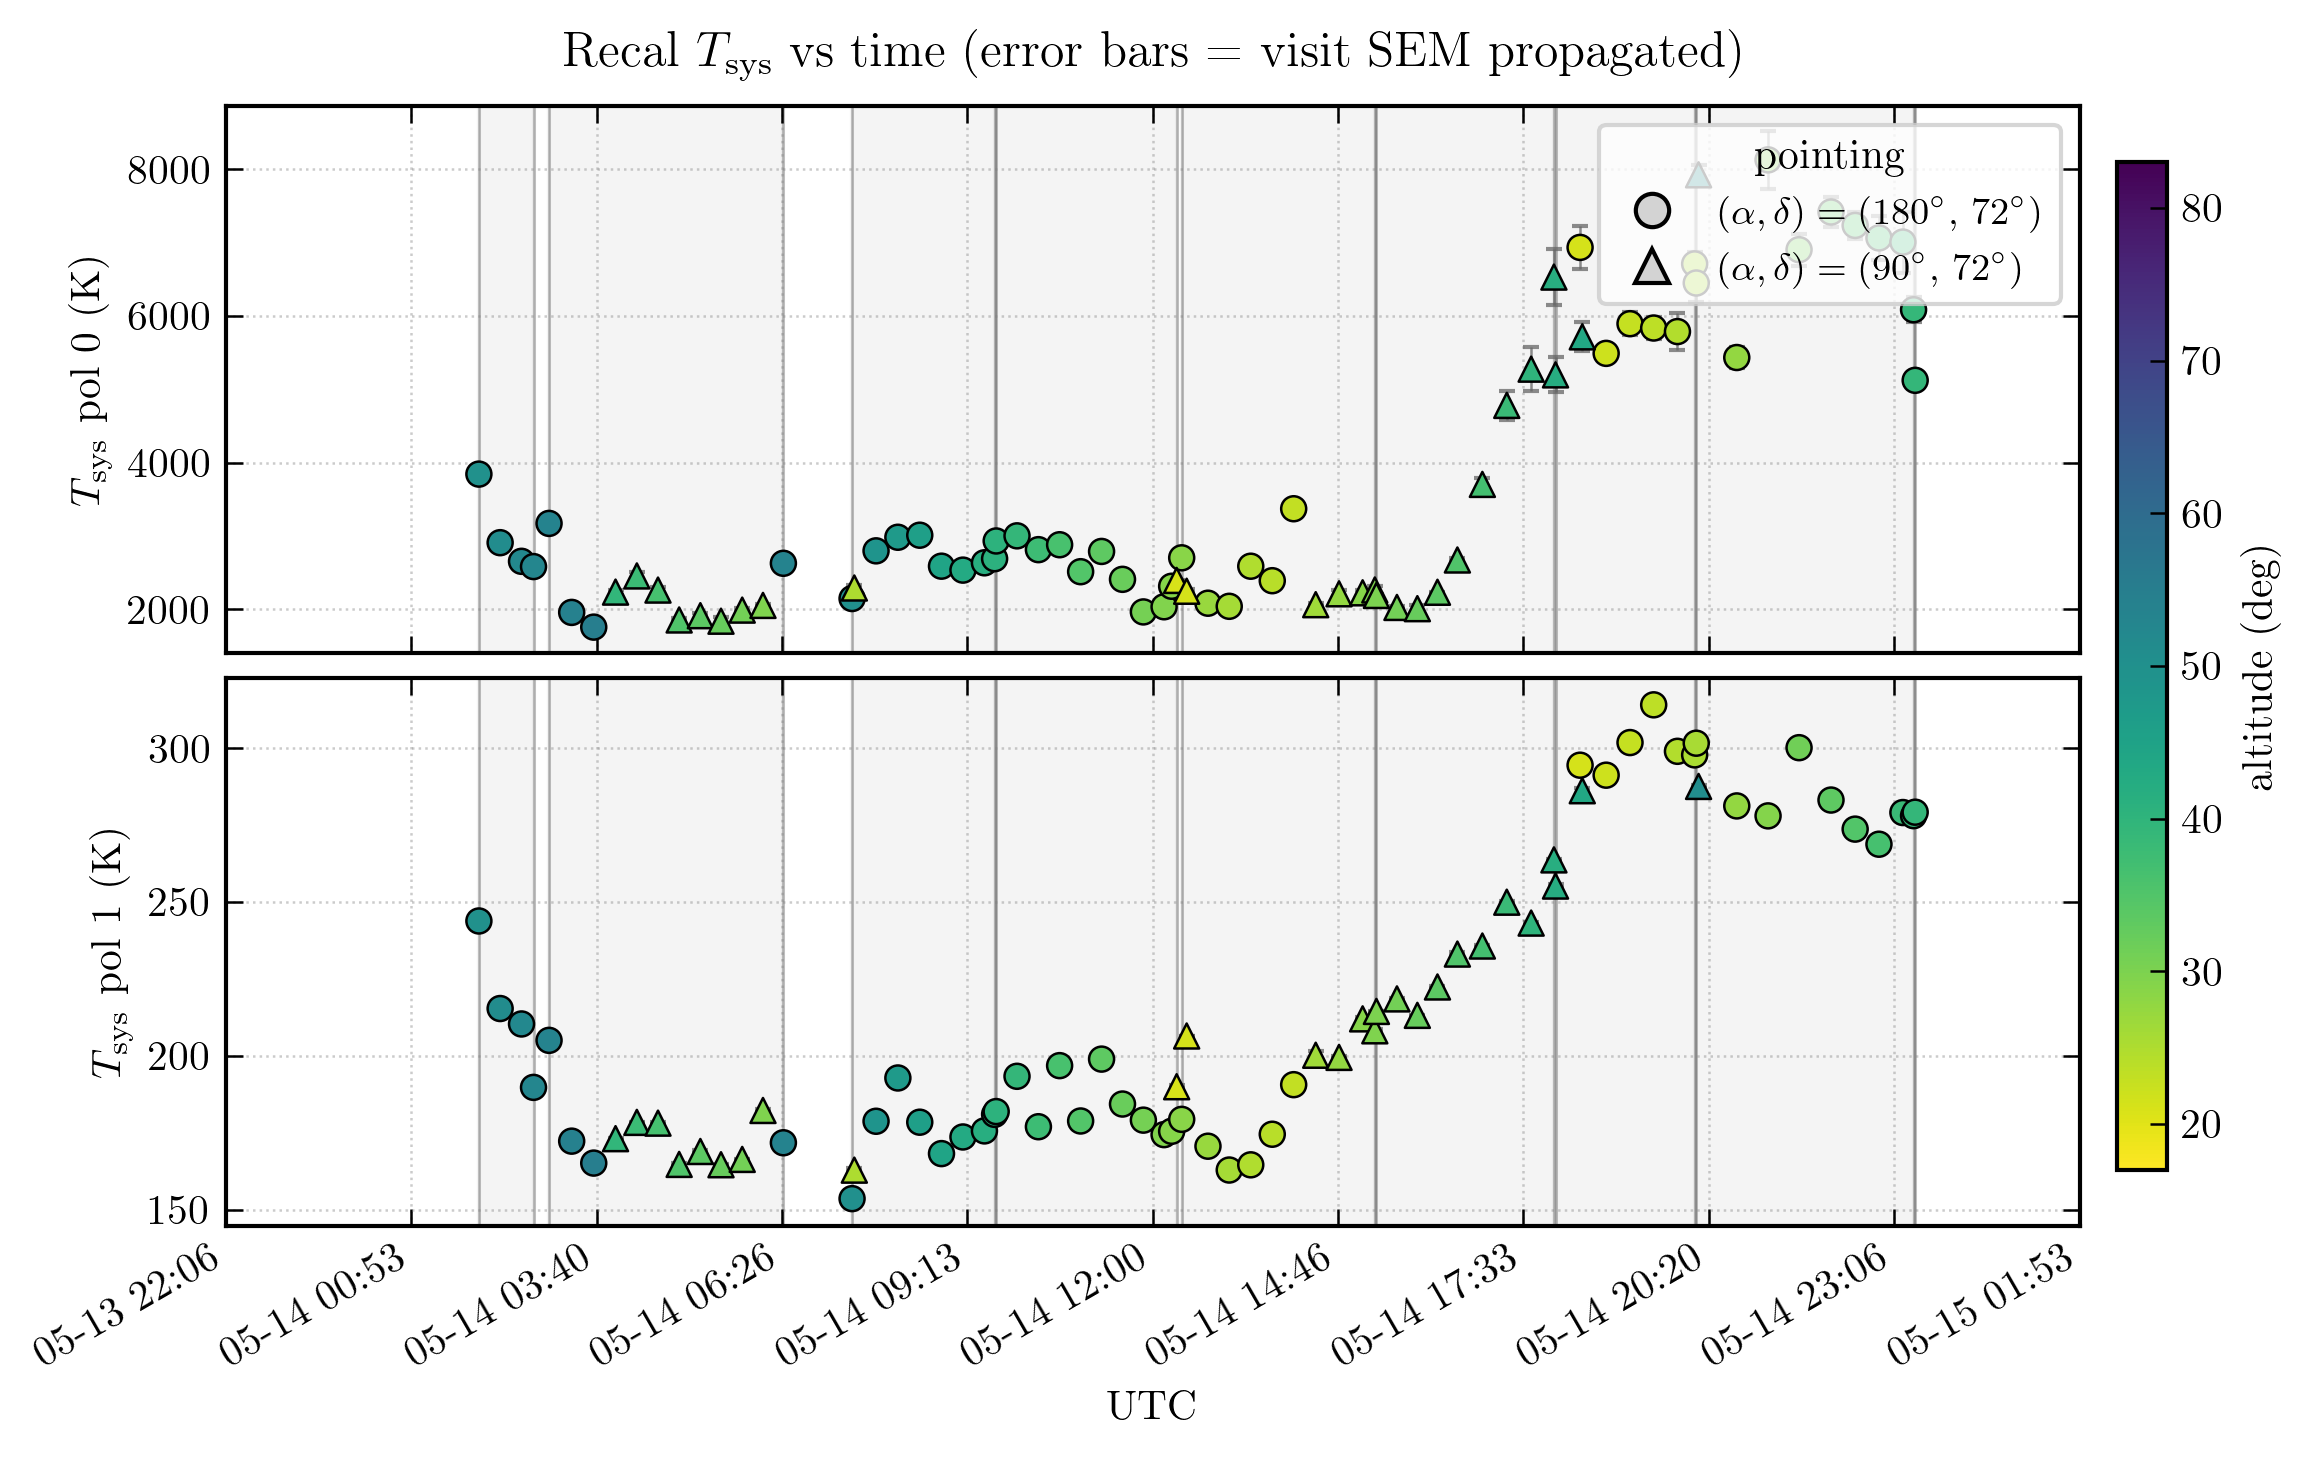

In [5]:
# Two stacked panels (pol 0 and pol 1), session-span shading,
# marker = pointing (circle vs triangle), face colour = altitude.
pointings = sorted(tsys_df['target_id'].unique())
markers = dict(zip(pointings, ['o', '^']))  # recal_drift -> circle, recal_drift_bk -> triangle

sessions = sorted(tsys_df['session'].unique())
session_spans = {
    s: (tsys_df.loc[tsys_df['session'] == s, 't_mid'].min(),
        tsys_df.loc[tsys_df['session'] == s, 't_mid'].max())
    for s in sessions
}

# Anchor colour scale to telescope altitude limits (Leuschner: 17-83 deg).
# Reversed viridis so brighter = lower altitude, darker = higher.
alt_min, alt_max = 17.0, 83.0
cmap = plt.cm.viridis_r

pt_colors = {tid: f'C{i}' for i, tid in enumerate(pointings)}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid in pointings:
        sub = tsys_df[(tsys_df['pol'] == pol_idx) & (tsys_df['target_id'] == tid)]
        # SEM error bars (from per-channel propagation, weighted-mean reduced).
        ax.errorbar(sub['t_mid'], sub['tsys'], yerr=sub['sigma_tsys'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(sub['t_mid'], sub['tsys'], c=sub['alt'],
                        cmap=cmap, vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.set_ylabel(rf'$T_{{\rm sys}}$ pol {pol_idx} (K)')

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=marker_handles, loc='upper right', frameon=True,
               title='pointing')

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(r'Recal $T_{\rm sys}$ vs time (error bars = visit SEM propagated)')
plt.show()

## 4. Per-pol R at recal pointings

The outlier-dump filter was applied in section 2. Here, attach a
per-pol frequency-switched ratio `R_pol(nu)` to every visit, computed
from the visit-averaged noise-off power at LO1 and LO2.


In [6]:
def add_per_pol_R(visits):
    """Scalar R_pol per visit per pol: R = (p_off_LO1 - p_off_LO2)/p_off_LO2.

    var_R = (sp1/p2)^2 + (p1 sp2 / p2^2)^2 by Gaussian propagation.
    """
    for v in visits:
        for pol_idx in (0, 1):
            p1, p2 = v[f'p_off_pol{pol_idx}_lo1'], v[f'p_off_pol{pol_idx}_lo2']
            s1, s2 = v[f'sp_off_pol{pol_idx}_lo1'], v[f'sp_off_pol{pol_idx}_lo2']
            if not (np.isfinite(p1) and np.isfinite(p2)
                    and np.isfinite(s1) and np.isfinite(s2)) or p2 == 0:
                v[f'R_pol{pol_idx}']  = np.nan
                v[f'sR_pol{pol_idx}'] = np.nan
                continue
            v[f'R_pol{pol_idx}'] = float((p1 - p2) / p2)
            var_R = (s1 / p2)**2 + (p1 * s2 / p2**2)**2
            v[f'sR_pol{pol_idx}'] = float(np.sqrt(var_R))


add_per_pol_R(gain_visits)
print('Per-pol scalar R and sigma_R attached to all visits.')


Per-pol scalar R and sigma_R attached to all visits.


## 5. Cross-pointing visit pairs (|dt| <= 600 s)

Pair each visit of pointing A with the nearest-in-time visit of
pointing B that is still within `DT_MAX_SEC`. The first chronological
pair becomes the anchor; later pairs serve as consistency checks for
the "diode hasn't drifted between A and B" assumption.


In [7]:
DT_MAX_SEC = 600.0

visits_A = sorted([v for v in gain_visits if v['target_id'] == pointings[0]],
                  key=lambda v: v['t_mid'])
visits_B = sorted([v for v in gain_visits if v['target_id'] == pointings[1]],
                  key=lambda v: v['t_mid'])
print(f'Pointing A ({pointings[0]}): {len(visits_A)} visits')
print(f'Pointing B ({pointings[1]}): {len(visits_B)} visits')

pairs = []
used_B = set()
for vA in visits_A:
    if not visits_B:
        break
    vB = min(visits_B, key=lambda v: abs(v['t_mid'] - vA['t_mid']))
    if abs(vB['t_mid'] - vA['t_mid']) > DT_MAX_SEC:
        continue
    key = (vB['session'], vB['visit_idx'])
    if key in used_B:
        continue
    used_B.add(key)
    pairs.append((vA, vB))

print(f'\n{len(pairs)} cross-pointing pairs within {DT_MAX_SEC:.0f}s')
for i, (vA, vB) in enumerate(pairs[:8]):
    print(f'  {i:2d}: A={dt.datetime.fromtimestamp(vA["t_mid"], dt.UTC):%Y-%m-%d %H:%M}, '
          f'B={dt.datetime.fromtimestamp(vB["t_mid"], dt.UTC):%H:%M}, '
          f'|dt|={abs(vA["t_mid"] - vB["t_mid"]):.0f}s')


Pointing A (recal_drift): 48 visits
Pointing B (recal_drift_bk): 27 visits

5 cross-pointing pairs within 600s
   0: A=2026-05-14 07:29, B=07:31, |dt|=123s
   1: A=2026-05-14 12:16, B=12:21, |dt|=269s
   2: A=2026-05-14 12:26, B=12:30, |dt|=268s
   3: A=2026-05-14 18:24, B=18:26, |dt|=118s
   4: A=2026-05-14 20:07, B=20:10, |dt|=211s


## 6. Anchor solve at t0 (cross-pointing + cross-pol)

First chronological pair `(t0_A, t0_B)` is the anchor:

1. Stipulate `Tcal11A(t0_A, nu) = 100 K` (channel-flat).
2. By time proximity, `Tcal11B(t0_B, nu) = Tcal11A(t0_A, nu)`.
3. `T_sys_11X(nu, t0) = Tcal11X * P_off_11X / (P_on - P_off)_11X` per
   pointing.
4. Cross-pol bridge:
   `T_sys_00X(nu, t0) = T_sys_11X(nu, t0) * R_11X(nu, t0) / R_00X(nu, t0)`.
5. Back-solve `Tcal00X(nu, t0) = T_sys_00X * dP_00X / P_off_00X`.
6. Freeze the per-pointing sky brightness:
   `T_B_X(nu) = T_sys_11X(nu, t0) * R_11X(nu, t0)` -- input to section 9.


In [8]:
TCAL11A_ANCHOR_K = 100.0  # placeholder; refine via known extended-object cal later

anchor_A, anchor_B = pairs[0]
print('Anchor pair (first chronological cross-pointing tie):')
print(f'  A: target={anchor_A["target_id"]}, '
      f't={dt.datetime.fromtimestamp(anchor_A["t_mid"], dt.UTC):%Y-%m-%d %H:%M UTC}')
print(f'  B: target={anchor_B["target_id"]}, '
      f't={dt.datetime.fromtimestamp(anchor_B["t_mid"], dt.UTC):%Y-%m-%d %H:%M UTC}')
print(f'  |dt| = {abs(anchor_A["t_mid"] - anchor_B["t_mid"]):.0f} s')


def visit_p_lo_avg(visit, pol_idx, kind):
    """LO-averaged scalar `p_{kind}` and its variance.

    var(p_avg) = sum(var_lo) / N_lo^2 assuming independent LO captures.
    """
    ps  = [visit[f'{kind}_pol{pol_idx}_lo{lo}']  for lo, _ in LOS]
    sps = [visit[f's{kind}_pol{pol_idx}_lo{lo}'] for lo, _ in LOS]
    pairs_ = [(p, s) for p, s in zip(ps, sps)
              if np.isfinite(p) and np.isfinite(s)]
    if not pairs_:
        return np.nan, np.nan
    p_avg = float(np.mean([p for p, _ in pairs_]))
    var   = float(np.sum([s**2 for _, s in pairs_])) / len(pairs_)**2
    return p_avg, var


def visit_dp_avg(visit, pol_idx):
    """LO-averaged scalar (p_on - p_off) and its variance."""
    pon,  von  = visit_p_lo_avg(visit, pol_idx, 'p_on')
    poff, voff = visit_p_lo_avg(visit, pol_idx, 'p_off')
    return pon - poff, von + voff


# Note on independence: p_off enters both R_pol and T_sys; strict
# propagation would carry a covariance term.  Treated as independent
# (standard first-order Gaussian propagation, common in radiometry).

# 1-2. Tcal_11 anchor stipulation (sigma = 0 for the 100 K choice).
Tcal11_anchor     = TCAL11A_ANCHOR_K
var_Tcal11_anchor = 0.0

# 3. T_sys_11X = Tcal_11 * p_off_11 / (p_on_11 - p_off_11).
p_off_11A, vp_off_11A = visit_p_lo_avg(anchor_A, 1, 'p_off')
p_on_11A,  vp_on_11A  = visit_p_lo_avg(anchor_A, 1, 'p_on')
dp_11A,    vdp_11A    = visit_dp_avg(anchor_A, 1)
p_off_11B, vp_off_11B = visit_p_lo_avg(anchor_B, 1, 'p_off')
p_on_11B,  vp_on_11B  = visit_p_lo_avg(anchor_B, 1, 'p_on')
dp_11B,    vdp_11B    = visit_dp_avg(anchor_B, 1)

T_sys_11A_t0 = Tcal11_anchor * p_off_11A / dp_11A
T_sys_11B_t0 = Tcal11_anchor * p_off_11B / dp_11B
var_T_sys_11A = (Tcal11_anchor / dp_11A**2)**2 * (
    p_on_11A**2 * vp_off_11A + p_off_11A**2 * vp_on_11A)
var_T_sys_11B = (Tcal11_anchor / dp_11B**2)**2 * (
    p_on_11B**2 * vp_off_11B + p_off_11B**2 * vp_on_11B)

# 4. Cross-pol bridge -> T_sys_00X = T_sys_11X * R_11X / R_00X.
R_11A, sR_11A = anchor_A['R_pol1'], anchor_A['sR_pol1']
R_00A, sR_00A = anchor_A['R_pol0'], anchor_A['sR_pol0']
R_11B, sR_11B = anchor_B['R_pol1'], anchor_B['sR_pol1']
R_00B, sR_00B = anchor_B['R_pol0'], anchor_B['sR_pol0']

T_sys_00A_t0 = T_sys_11A_t0 * R_11A / R_00A
T_sys_00B_t0 = T_sys_11B_t0 * R_11B / R_00B
rel2_TsA = (var_T_sys_11A / T_sys_11A_t0**2
            + (sR_11A / R_11A)**2 + (sR_00A / R_00A)**2)
rel2_TsB = (var_T_sys_11B / T_sys_11B_t0**2
            + (sR_11B / R_11B)**2 + (sR_00B / R_00B)**2)
var_T_sys_00A = T_sys_00A_t0**2 * rel2_TsA
var_T_sys_00B = T_sys_00B_t0**2 * rel2_TsB

# 5. Tcal_00 anchor = T_sys_00 * dp_00 / p_off_00.
p_off_00A, vp_off_00A = visit_p_lo_avg(anchor_A, 0, 'p_off')
dp_00A,    vdp_00A    = visit_dp_avg(anchor_A, 0)
p_off_00B, vp_off_00B = visit_p_lo_avg(anchor_B, 0, 'p_off')
dp_00B,    vdp_00B    = visit_dp_avg(anchor_B, 0)

Tcal00A_t0 = T_sys_00A_t0 * dp_00A / p_off_00A
Tcal00B_t0 = T_sys_00B_t0 * dp_00B / p_off_00B
var_Tcal00A = Tcal00A_t0**2 * (rel2_TsA
                               + vdp_00A / dp_00A**2
                               + vp_off_00A / p_off_00A**2)
var_Tcal00B = Tcal00B_t0**2 * (rel2_TsB
                               + vdp_00B / dp_00B**2
                               + vp_off_00B / p_off_00B**2)

# 6. T_B_X = T_sys_11X * R_11X (frozen per pointing).
T_B_A = T_sys_11A_t0 * R_11A
T_B_B = T_sys_11B_t0 * R_11B
var_T_B_A = T_B_A**2 * (var_T_sys_11A / T_sys_11A_t0**2
                        + (sR_11A / R_11A)**2)
var_T_B_B = T_B_B**2 * (var_T_sys_11B / T_sys_11B_t0**2
                        + (sR_11B / R_11B)**2)


def _s(v):
    return float(np.sqrt(v))


print('\nAnchor solve (band-averaged scalar form):')
print(f'  T_sys_11A = {T_sys_11A_t0:7.1f} +/- {_s(var_T_sys_11A):5.2f} K     '
      f'T_sys_11B = {T_sys_11B_t0:7.1f} +/- {_s(var_T_sys_11B):5.2f} K')
print(f'  T_sys_00A = {T_sys_00A_t0:7.1f} +/- {_s(var_T_sys_00A):5.2f} K     '
      f'T_sys_00B = {T_sys_00B_t0:7.1f} +/- {_s(var_T_sys_00B):5.2f} K')
print(f'  Tcal00A   = {Tcal00A_t0:7.1f} +/- {_s(var_Tcal00A):5.2f} K     '
      f'Tcal00B   = {Tcal00B_t0:7.1f} +/- {_s(var_Tcal00B):5.2f} K')
print(f'  T_B_A     = {T_B_A:8.3g} +/- {_s(var_T_B_A):.2g}     '
      f'T_B_B     = {T_B_B:8.3g} +/- {_s(var_T_B_B):.2g}')


Anchor pair (first chronological cross-pointing tie):
  A: target=recal_drift, t=2026-05-14 07:29 UTC
  B: target=recal_drift_bk, t=2026-05-14 07:31 UTC
  |dt| = 123 s

Anchor solve (band-averaged scalar form):
  T_sys_11A =   188.5 +/-  1.23 K     T_sys_11B =   204.2 +/-  0.74 K
  T_sys_00A = -2022.5 +/- 567.23 K     T_sys_00B =   384.8 +/- 28.26 K
  Tcal00A   =   -54.5 +/- 15.46 K     Tcal00B   =     9.5 +/-  0.72 K
  T_B_A     =     3.11 +/- 0.35     T_B_B     =        4 +/- 0.16


## 7. Propagate scalar `Tcal_pol(t, X)` to all recal visits

Under constant `T_B_X` at each pointing:

    T_sys_pol(t, X) = T_B_X / R_pol(t, X)
    Tcal_pol(t, X)  = T_sys_pol(t, X) * dp_pol(t, X) / p_off_pol(t, X)

All quantities are scalars (band-averaged at section 2).  Result is one
calibrated point per visit per pol per pointing, with propagated SEM.


In [9]:
def propagate_scalar(visits, T_B_X, var_T_B_X):
    """Per-visit scalar Tcal_pol with propagated SEM.

    T_B_X is frozen at the anchor; its variance is common-mode across
    visits, so it does not move points relative to one another but does
    set the overall scale uncertainty.
    """
    rows = []
    for v in visits:
        row = {'t_mid': v['t_mid'], 'session': v['session'],
               'target_id': v['target_id'], 'alt': v['alt_mean']}
        for pol_idx in (0, 1):
            R, sR = v[f'R_pol{pol_idx}'], v[f'sR_pol{pol_idx}']
            if not np.isfinite(R) or R == 0:
                row[f'T_sys_pol{pol_idx}']       = np.nan
                row[f'sigma_T_sys_pol{pol_idx}'] = np.nan
                row[f'Tcal_pol{pol_idx}']        = np.nan
                row[f'sigma_Tcal_pol{pol_idx}']  = np.nan
                continue
            poff, vpoff = visit_p_lo_avg(v, pol_idx, 'p_off')
            dp,   vdp   = visit_dp_avg(v, pol_idx)

            T_sys     = T_B_X / R
            rel2_Tsys = var_T_B_X / T_B_X**2 + (sR / R)**2
            var_Tsys  = T_sys**2 * rel2_Tsys

            Tcal     = T_sys * dp / poff
            var_Tcal = Tcal**2 * (rel2_Tsys + vdp / dp**2 + vpoff / poff**2)

            row[f'T_sys_pol{pol_idx}']       = T_sys
            row[f'sigma_T_sys_pol{pol_idx}'] = float(np.sqrt(var_Tsys))
            row[f'Tcal_pol{pol_idx}']        = Tcal
            row[f'sigma_Tcal_pol{pol_idx}']  = float(np.sqrt(var_Tcal))
        rows.append(row)
    return pd.DataFrame(rows)


dfA_s = propagate_scalar(visits_A, T_B_A, var_T_B_A)
dfB_s = propagate_scalar(visits_B, T_B_B, var_T_B_B)
print(f'Propagated scalar Tcal: {len(dfA_s)} A visits, {len(dfB_s)} B visits.')


Propagated scalar Tcal: 48 A visits, 27 B visits.


## 8. Tcal(t) scalar drift per pointing

One band-averaged scalar per visit per pol per pointing, with
propagated SEM as error bars.  Horizontal dashed lines mark the
anchor Tcal value per pointing; vertical dotted red lines mark the
anchor visit times.  Marker = pointing, colour = altitude.


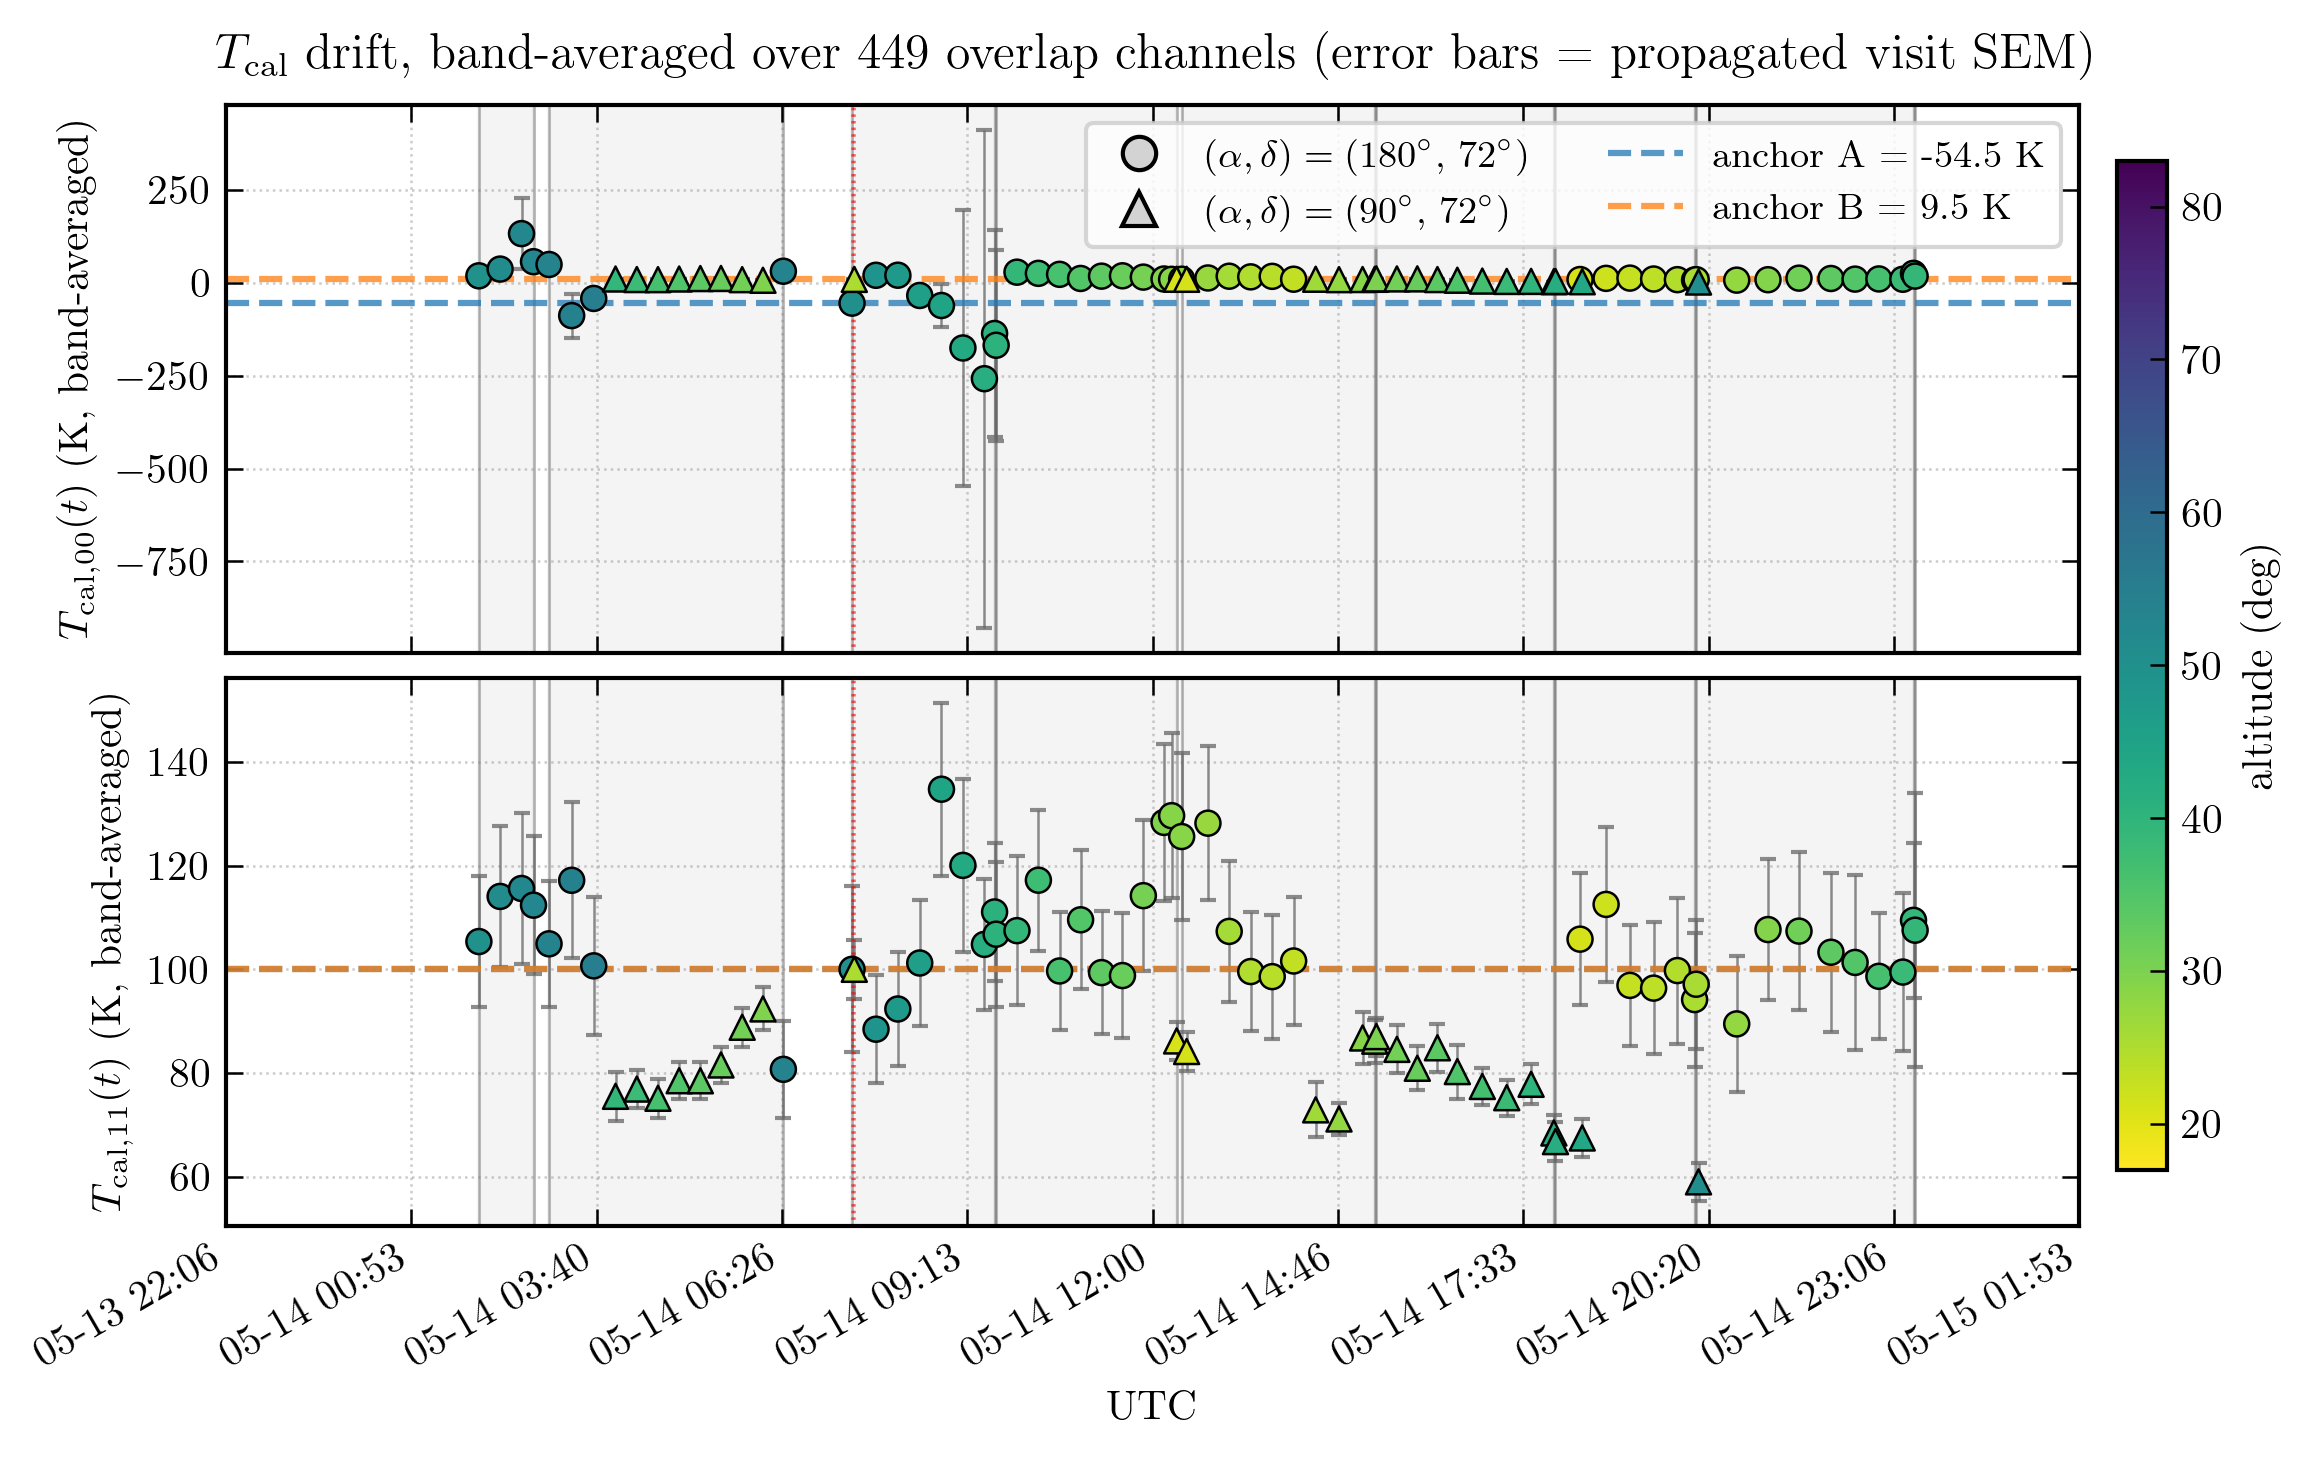

In [10]:
## Section 8 plot moved here from the deleted §9.  Tcal scalar drift,
## one point per visit per pol per pointing, with propagated SEM bars.

anchor_vals_s = {
    0: (Tcal00A_t0, Tcal00B_t0),
    1: (TCAL11A_ANCHOR_K, TCAL11A_ANCHOR_K),
}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid, df_pt in zip(pointings, (dfA_s, dfB_s)):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.axhline(anchor_vals_s[pol_idx][0], color=pt_colors[pointings[0]],
               **MODEL_STYLE,
               label=f'anchor A = {anchor_vals_s[pol_idx][0]:.1f} K')
    ax.axhline(anchor_vals_s[pol_idx][1], color=pt_colors[pointings[1]],
               **MODEL_STYLE,
               label=f'anchor B = {anchor_vals_s[pol_idx][1]:.1f} K')
    ax.axvline(anchor_A['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.axvline(anchor_B['t_mid'], color='red', lw=LW_FINE, ls=':',
               alpha=ALPHA_LIGHT)
    ax.set_ylabel(
        rf'$T_{{\rm cal,{pol_idx}{pol_idx}}}(t)$ (K, band-averaged)'
    )

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=(marker_handles
                        + axes[0].get_legend_handles_labels()[0]),
               loc='upper right', frameon=True, ncol=2)

xticks = axes[1].get_xticks()
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[1].set_xlabel('UTC')

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(
    rf'$T_{{\rm cal}}$ drift, band-averaged over {INT_MASK.sum()} '
    rf'overlap channels (error bars = propagated visit SEM)'
)
plt.show()


## 9. Cross-pointing renormalisation (Tcal is pointing-independent)

The diode sits in the receiver chain, so the *true* `Tcal_pol(t)` does
not depend on telescope pointing.  Section 8's two tracks split because
the per-pointing scale factor `T_B_X / R_anchor_X` was fixed by a single
anchor visit per pointing; for pol 0 the cross-pol bridge amplifies the
asymmetry.

Here we use **every** A-B visit pair within `DT_MAX_SEC_RENORM` (loosened
from 600 s) to enforce `Tcal_A(t_A) = Tcal_B(t_B)` and back out the
inter-pointing scale `s_pol = mean(Tcal_A/Tcal_B)`, then rescale B onto
A's ladder.  If the divergence in section 8 is purely a constant
anchor-asymmetric multiplicative offset, the renormalised tracks should
overlay within propagated visit SEM.  Residual structure in
`Tcal_A/Tcal_B` vs time would indicate a *time-varying* differential
(atmosphere / elevation systematic), not a calibration constant.


### Expressing `s_pol` in terms of `Tcal` and `T_sys`

From the radiometer identity `dP/P_off = Tcal_true / T_sys_true`, the
recovered (frozen-anchor) `Tcal` at any visit is

$$
T_{\rm cal}^{\rm rec}(t, X) \;=\; \underbrace{\frac{T_{B,X}}{R_{\rm anchor,X}}}_{\equiv\,T_{\rm sys}^{\rm anchor}(X)} \cdot \frac{dP(t,X)}{P_{\rm off}(t,X)} \;=\; T_{\rm cal}^{\rm true}(t)\,\cdot\,\frac{T_{\rm sys}^{\rm anchor}(X)}{T_{\rm sys}^{\rm true}(t,X)}\,.
$$

Forming the pair ratio at near-simultaneous `(t_A, t_B)` where the true
diode is pointing-independent (`Tcal_true(t_A) = Tcal_true(t_B)`) gives

$$
s_{\rm pol} \;\equiv\; \frac{T_{\rm cal,A}^{\rm rec}(t_A)}{T_{\rm cal,B}^{\rm rec}(t_B)} \;=\; \underbrace{\frac{T_{\rm sys}^{\rm anchor}(A)}{T_{\rm sys}^{\rm anchor}(B)}}_{\text{frozen at }t_0} \;\cdot\; \underbrace{\frac{T_{\rm sys}^{\rm true}(t_B,B)}{T_{\rm sys}^{\rm true}(t_A,A)}}_{\text{current }T_{\rm sys}\text{ ratio}}\,.
$$

**Pol 1 (`s_1`).** The anchor stipulation `Tcal_11A(t_0) = Tcal_11B(t_0) = 100\,$K rewrites the first factor as
$T_{\rm sys}^{\rm anchor}(X) = 100\,$K$\cdot T_{\rm sys}^{\rm true}(t_0,X)/T_{\rm cal}^{\rm true}(t_0)$, so

$$
s_1 \;=\; \frac{T_{\rm sys,11}^{\rm true}(t_0,A)}{T_{\rm sys,11}^{\rm true}(t_0,B)} \,\cdot\, \frac{T_{\rm sys,11}^{\rm true}(t_B,B)}{T_{\rm sys,11}^{\rm true}(t_A,A)}\,.
$$

If `T_sys_A/T_sys_B` has not changed since the anchor, `s_1 = 1`.  Departure
from unity is **the differential evolution of `T_sys` between the two
pointings since `t_0`** -- e.g. one pointing has dropped in elevation
more than the other, atmosphere has thickened differently, etc.

**Pol 0 (`s_0`).** Pol 0's anchor scale is set via the cross-pol bridge,
`T_sys_00X(t_0) = T_sys_11X(t_0) \cdot R_11X(t_0)/R_00X(t_0)`, so

$$
s_0 \;=\; \underbrace{\frac{R_{11A}(t_0)/R_{00A}(t_0)}{R_{11B}(t_0)/R_{00B}(t_0)}}_{\text{cross-pol bridge asymmetry}} \,\cdot\, \underbrace{\frac{T_{\rm sys,11}^{\rm true}(t_0,A)}{T_{\rm sys,11}^{\rm true}(t_0,B)} \cdot \frac{T_{\rm sys,00}^{\rm true}(t_B,B)}{T_{\rm sys,00}^{\rm true}(t_A,A)}}_{\text{anchor and current }T_{\rm sys}\text{ ratios}}\,.
$$

Even if the two pointings have identical `T_sys` evolution, `s_0` carries
the cross-pol bridge factor `(R_11/R_00)_A / (R_11/R_00)_B`, which
differs from unity whenever the two pointings have different HI signal
balance, polarised RFI, or pol-0 noise-diode coupling.  This is the
extra term that makes pol 0 unreliable -- the 3.2 MHz coupling flagged
in `CLAUDE.md` lives entirely in this factor.

**Summary:**
- `s_1 - 1` $\approx$ differential `T_sys` drift between pointings.
- `s_0` = (cross-pol bridge asymmetry) $\times$ (differential `T_sys` drift).


In [11]:
# DT_MAX_SEC_RENORM controls how strict the simultaneity gate is.
# 600 s: same gate as the anchor search in section 5.  Tight enough
# that any diode drift between A and B inside a pair is negligible.
DT_MAX_SEC_RENORM = 600.0

def find_pairs(dfA_, dfB_, dt_max):
    """Nearest-time A-B pair list, A side uniquely matched."""
    used_B = set()
    pairs = []
    for iA, rA in dfA_.iterrows():
        cand = dfB_[~dfB_.index.isin(used_B)]
        if cand.empty:
            break
        dt = (cand['t_mid'] - rA['t_mid']).abs()
        iB = dt.idxmin()
        if dt.loc[iB] > dt_max:
            continue
        used_B.add(iB)
        pairs.append((iA, iB, float(dt.loc[iB])))
    return pairs


pairs_renorm = find_pairs(dfA_s, dfB_s, DT_MAX_SEC_RENORM)
print(f'{len(pairs_renorm)} A-B pairs within {DT_MAX_SEC_RENORM:.0f} s '
      f'(was 1 within 600 s).')


def ratio_with_sigma(TA, sA, TB, sB):
    if not (np.isfinite(TA) and np.isfinite(TB)) or TB == 0:
        return np.nan, np.nan
    r = TA / TB
    var = r**2 * ((sA / TA)**2 + (sB / TB)**2)
    return r, float(np.sqrt(var))


ratios_per_pol = {0: [], 1: []}
ratio_times    = {0: [], 1: []}
for iA, iB, _ in pairs_renorm:
    rA, rB = dfA_s.loc[iA], dfB_s.loc[iB]
    t_mid_pair = 0.5 * (rA['t_mid'] + rB['t_mid'])
    for pol_idx in (0, 1):
        r, sr = ratio_with_sigma(
            rA[f'Tcal_pol{pol_idx}'], rA[f'sigma_Tcal_pol{pol_idx}'],
            rB[f'Tcal_pol{pol_idx}'], rB[f'sigma_Tcal_pol{pol_idx}'],
        )
        if np.isfinite(r) and np.isfinite(sr) and sr > 0:
            ratios_per_pol[pol_idx].append((r, sr))
            ratio_times[pol_idx].append(t_mid_pair)

scale = {}
scale_sigma = {}
for pol_idx in (0, 1):
    pl = ratios_per_pol[pol_idx]
    if pl:
        vals = np.array([r for r, _ in pl])
        sigs = np.array([s for _, s in pl])
        w = 1.0 / sigs**2
        scale[pol_idx]       = float(np.sum(w * vals) / np.sum(w))
        scale_sigma[pol_idx] = float(1.0 / np.sqrt(np.sum(w)))
    else:
        scale[pol_idx], scale_sigma[pol_idx] = 1.0, 0.0
    print(f'  pol {pol_idx}: s = Tcal_A/Tcal_B = '
          f'{scale[pol_idx]:.3f} +/- {scale_sigma[pol_idx]:.3f}  '
          f'(N={len(pl)} pairs)')

# Apply: rescale B onto A's ladder, propagate sigma multiplicatively
# (anchor-scale uncertainty added in quadrature later if you want it
# absolute; here we keep it as a relative renorm).
dfB_renorm = dfB_s.copy()
for pol_idx in (0, 1):
    dfB_renorm[f'Tcal_pol{pol_idx}']        = dfB_s[f'Tcal_pol{pol_idx}'] * scale[pol_idx]
    dfB_renorm[f'sigma_Tcal_pol{pol_idx}']  = dfB_s[f'sigma_Tcal_pol{pol_idx}'] * scale[pol_idx]


5 A-B pairs within 600 s (was 1 within 600 s).
  pol 0: s = Tcal_A/Tcal_B = 1.085 +/- 0.097  (N=5 pairs)
  pol 1: s = Tcal_A/Tcal_B = 1.387 +/- 0.089  (N=5 pairs)


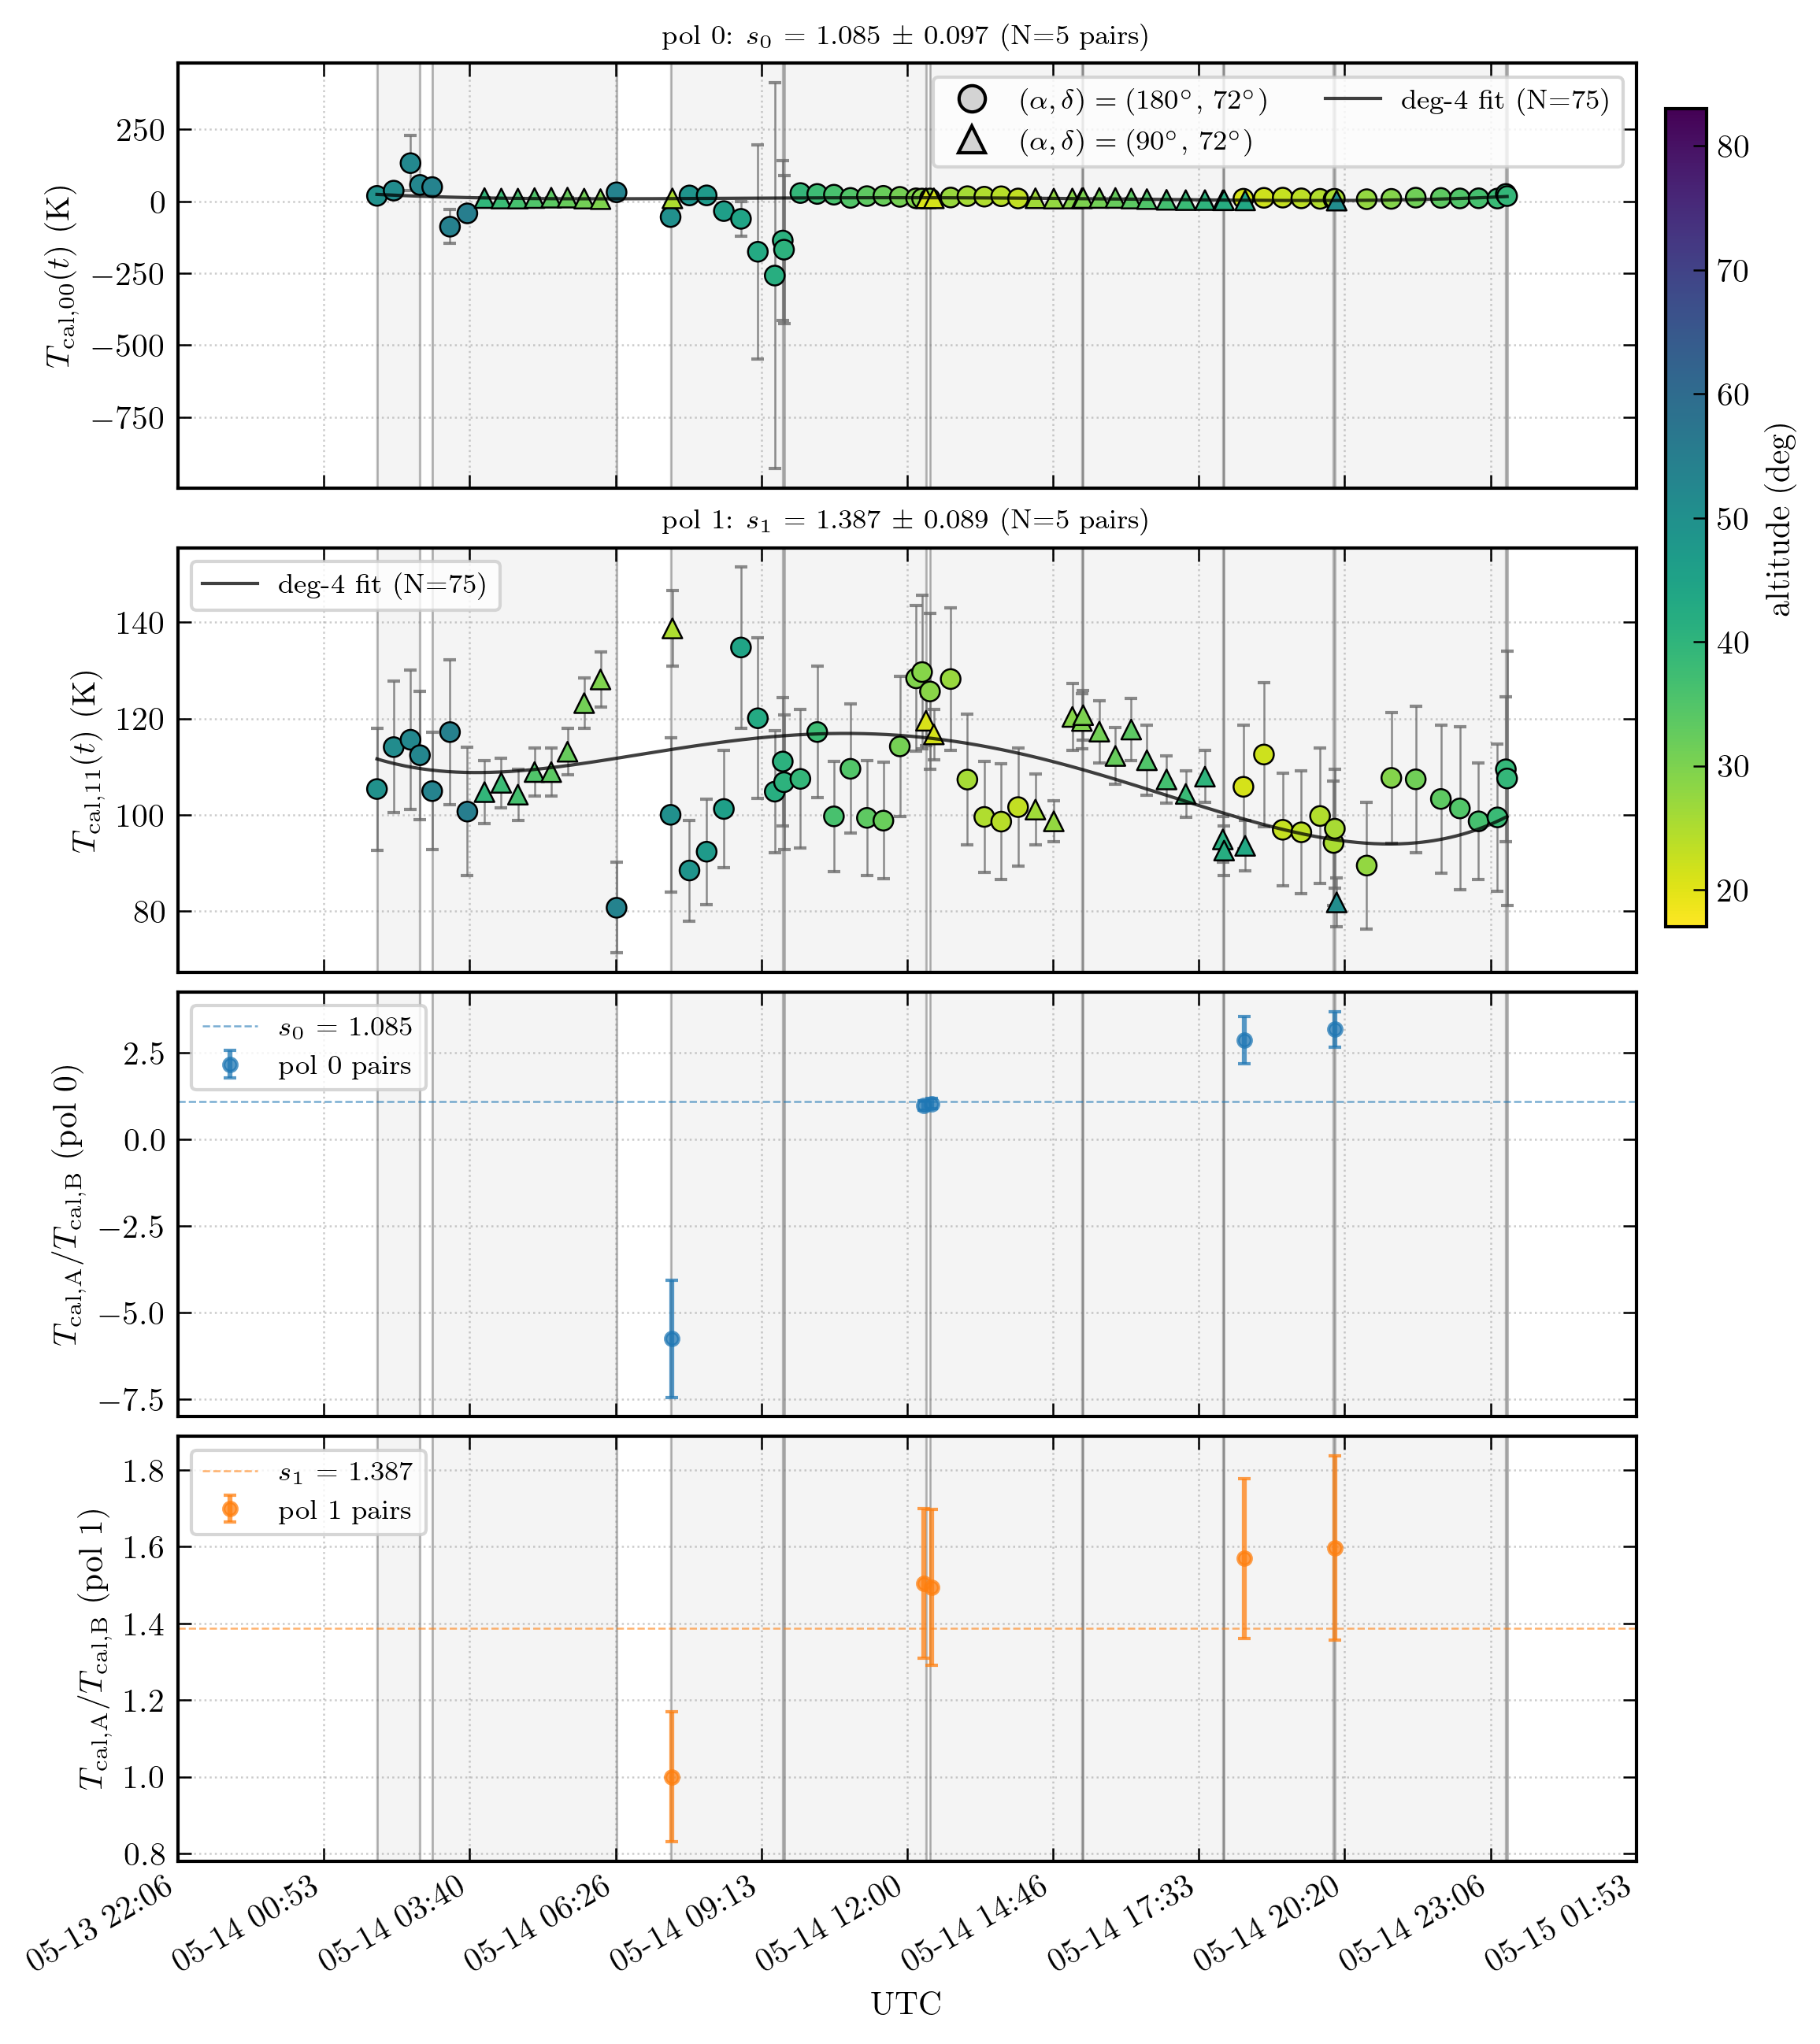

In [12]:
# 4-row plot: Tcal(t) tracks then Tcal_A/Tcal_B ratio, separated per pol.
# Rows 1-2: renormalised Tcal_A(t) and Tcal_B(t) overlaid (per pol),
# with a degree-8 polynomial fit through both A and B-renormalised points
# (weighted by 1/sigma^2).
# Rows 3-4: per-pair Tcal_A/Tcal_B ratio vs time, with the weighted-mean
# scale as a dashed line.

POLY_DEG = 4


def fit_tcal_poly(df_A, df_B, pol_idx, deg=POLY_DEG):
    """Weighted polynomial fit through combined A + B-renormalised points.

    Uses numpy.polynomial.Polynomial.fit which auto-scales the domain,
    avoiding ill-conditioned matrices on raw unix timestamps.
    """
    t  = np.concatenate([df_A['t_mid'].values, df_B['t_mid'].values])
    y  = np.concatenate([df_A[f'Tcal_pol{pol_idx}'].values,
                         df_B[f'Tcal_pol{pol_idx}'].values])
    sy = np.concatenate([df_A[f'sigma_Tcal_pol{pol_idx}'].values,
                         df_B[f'sigma_Tcal_pol{pol_idx}'].values])
    good = np.isfinite(t) & np.isfinite(y) & np.isfinite(sy) & (sy > 0)
    if good.sum() <= deg:
        return None, good.sum()
    poly = np.polynomial.Polynomial.fit(t[good], y[good], deg,
                                        w=1.0 / sy[good])
    return poly, int(good.sum())


fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 18 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 4, sharex=True)

sc = None
# Rows 0, 1: Tcal tracks per pol (A unchanged, B x s_pol) + poly fit.
t_all = np.concatenate([dfA_s['t_mid'].values, dfB_renorm['t_mid'].values])
t_dense = np.linspace(np.nanmin(t_all), np.nanmax(t_all), 400)

for ax, pol_idx in zip(axes[:2], (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid, df_pt in zip(pointings, (dfA_s, dfB_renorm)):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    poly, n_fit = fit_tcal_poly(dfA_s, dfB_renorm, pol_idx)
    if poly is not None:
        ax.plot(t_dense, poly(t_dense), color='k', lw=LW_LIGHT,
                alpha=ALPHA_STANDARD, zorder=4,
                label=f'deg-{POLY_DEG} fit (N={n_fit})')
        ax.legend(loc='upper left', frameon=True, fontsize='small')
    ax.set_ylabel(
        rf'$T_{{\rm cal,{pol_idx}{pol_idx}}}(t)$ (K)'
    )
    ax.set_title(rf'pol {pol_idx}: $s_{{{pol_idx}}}$ = '
                 rf'{scale[pol_idx]:.3f} $\pm$ '
                 rf'{scale_sigma[pol_idx]:.3f}  '
                 rf'(N={len(ratios_per_pol[pol_idx])} pairs)',
                 fontsize='small')

# Rows 2, 3: per-pair Tcal_A/Tcal_B ratio per pol.
for ax, pol_idx in zip(axes[2:], (0, 1)):
    _shade_sessions(ax, session_spans)
    ts = np.array(ratio_times[pol_idx])
    rs = np.array([r for r, _ in ratios_per_pol[pol_idx]])
    ss = np.array([s for _, s in ratios_per_pol[pol_idx]])
    if len(ts):
        ax.errorbar(ts, rs, yerr=ss, fmt='o', color=f'C{pol_idx}',
                    markersize=4, capsize=2, alpha=ALPHA_STANDARD,
                    label=f'pol {pol_idx} pairs')
        ax.axhline(scale[pol_idx], color=f'C{pol_idx}', ls='--',
                   lw=LW_FINE, alpha=ALPHA_LIGHT,
                   label=f'$s_{{{pol_idx}}}$ = {scale[pol_idx]:.3f}')
    ax.set_ylabel(
        rf'$T_{{\rm cal,A}}/T_{{\rm cal,B}}$ (pol {pol_idx})'
    )
    ax.legend(loc='best', frameon=True, fontsize='small')

# Marker legend on top panel (pointing).
marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=(marker_handles
                        + axes[0].get_legend_handles_labels()[0]),
               loc='upper right', frameon=True,
               fontsize='small', ncol=2)

xticks = axes[-1].get_xticks()
axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels(
    [dt.datetime.fromtimestamp(t, dt.UTC).strftime('%m-%d %H:%M')
     for t in xticks],
    rotation=30, ha='right',
)
axes[-1].set_xlabel('UTC')

if sc is not None:
    cbar = fig.colorbar(sc, ax=axes[:2], location='right',
                        fraction=0.04, pad=0.02, shrink=0.9)
    cbar.set_label('altitude (deg)')

plt.show()
